# Reinforcement Learning from Human Feedback (RLHF)
### How preference data becomes a trained model — and why PPO is the missing piece

This notebook covers two of RLHF's three stages in full:
- **Stage 1 — Supervised Fine-Tuning (SFT)**: adapting a pretrained model to a target behaviour
- **Stage 2 — Reward Model**: learning a scoring function from human preference comparisons

**Stage 3 — RL fine-tuning with PPO** is covered structurally here, with the full mathematics in the companion Actor-Critic notebook.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from itertools import combinations

# ── Dark theme ────────────────────────────────────────────────────────────────
BG      = '#0d1117'
SURFACE = '#161b22'
ACCENT  = '#e05c5c'
TEXT    = '#c9d1d9'
MUTED   = '#484f58'
BLUE    = '#58a6ff'
GREEN   = '#3fb950'
YELLOW  = '#d29922'

rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        MUTED,
    'grid.alpha':        0.3,
    'legend.facecolor':  SURFACE,
    'legend.edgecolor':  MUTED,
    'figure.dpi':        110,
})

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
print("Ready.")

Ready.


## Part 1 — The problem RLHF solves

A language model trained purely on next-token prediction learns to be a good *text completer*. It learns the statistical patterns of the internet — which means it also learns to produce confident-sounding misinformation, refuse nothing, and optimise for fluency over accuracy.

The core problem is that **the training objective (predict the next token) is not the same as the deployment objective (be helpful, honest, and harmless)**.

The naive fix — write down exactly what you want and train on it — runs into an immediate difficulty: human preferences are hard to specify as a loss function. You can't write an equation for "this response is better than that one". But humans can *compare* responses and say which they prefer. That's much easier to collect.

RLHF (Christiano et al., 2017; Ziegler et al., 2019; Ouyang et al., 2022 — the InstructGPT paper) turns that observation into a training pipeline:

```
Pretrained LM
      │
      ▼
Stage 1: Supervised Fine-Tuning (SFT)
      │   Train on human-written demonstrations of good behaviour
      ▼
Stage 2: Reward Model Training
      │   Humans compare pairs of outputs → learn a scalar scoring function
      ▼
Stage 3: RL Fine-Tuning (PPO)
          Use reward model as feedback signal to push SFT model further
```

Each stage is distinct. Each has its own loss function. Let's build them.

## Part 2 — Stage 1: Supervised Fine-Tuning (SFT)

### What it is

Take a pretrained base model. Fine-tune it on a curated dataset of (prompt, ideal response) pairs — written or heavily edited by humans to demonstrate the target behaviour.

The loss function is identical to pretraining: **cross-entropy on next-token prediction**. The difference is the *data* — you're training on demonstrations of good behaviour rather than raw internet text.

$$\mathcal{L}_{SFT} = -\sum_{t} \log P_{\theta}(y_t \mid x, y_{<t})$$

Where $x$ is the prompt, $y_t$ is the $t$-th token of the ideal response, and $y_{<t}$ is all previous response tokens. The model learns to continue prompts in the style and content of the demonstrations.

### Why it's not enough on its own

SFT is limited by the quality and coverage of demonstrations. You can only train on behaviours humans have explicitly written out. For nuanced preferences — tone, appropriate hedging, knowing when to say "I don't know" — demonstration data is expensive to collect and hard to get right.

SFT also has no mechanism for the model to *improve beyond the demonstrations*. It can learn to imitate; it can't learn to do better.

In [2]:
# ── SFT in miniature ──────────────────────────────────────────────────────────
# I'll represent a language model as a small softmax classifier over a toy
# vocabulary. The point is to see the cross-entropy loss and the shift in
# output distributions before and after fine-tuning.

VOCAB = ['helpful', 'harmful', 'uncertain', 'verbose', 'concise', 'evasive']
V = len(VOCAB)  # vocabulary size = 6

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

def cross_entropy(probs, target_idx):
    """Cross-entropy loss for a single token prediction."""
    return -np.log(probs[target_idx] + 1e-10)

# Base model logits: roughly uniform with slight bias toward verbose/evasive
# (as you might expect from raw internet text)
base_logits = np.array([0.2, 0.1, 0.3, 0.8, 0.1, 0.7])
base_probs  = softmax(base_logits)

print("Base model token probabilities:")
for token, prob in zip(VOCAB, base_probs):
    bar = '█' * int(prob * 50)
    print(f"  {token:12s}: {prob:.3f}  {bar}")

# SFT demonstrations say the ideal token is 'helpful'
target_idx = VOCAB.index('helpful')
print(f"\nSFT target token: '{VOCAB[target_idx]}'")
print(f"Base model loss on this target: {cross_entropy(base_probs, target_idx):.4f}")

Base model token probabilities:
  helpful     : 0.135  ██████
  harmful     : 0.123  ██████
  uncertain   : 0.150  ███████
  verbose     : 0.247  ████████████
  concise     : 0.123  ██████
  evasive     : 0.223  ███████████

SFT target token: 'helpful'
Base model loss on this target: 1.9995


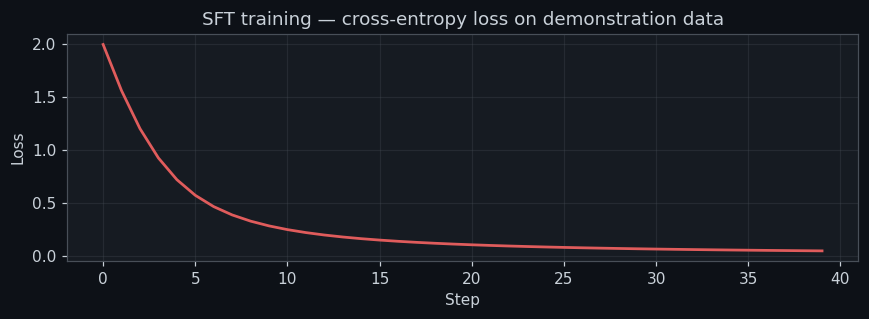


SFT model token probabilities (after fine-tuning):
  helpful     : 0.953  ███████████████████████████████████████████████
  harmful     : 0.008  
  uncertain   : 0.009  
  verbose     : 0.011  
  concise     : 0.008  
  evasive     : 0.011  


In [3]:
# ── Simulate SFT: gradient descent on cross-entropy ───────────────────────────
logits = base_logits.copy()
lr = 0.5
n_steps = 40
losses = []
prob_snapshots = []

for step in range(n_steps):
    probs = softmax(logits)
    loss  = cross_entropy(probs, target_idx)
    losses.append(loss)

    if step % 10 == 0:
        prob_snapshots.append((step, probs.copy()))

    # Gradient of cross-entropy w.r.t. logits:
    # dL/dz_i = p_i - 1(i == target)
    grad = probs.copy()
    grad[target_idx] -= 1.0
    logits -= lr * grad

sft_probs = softmax(logits)
prob_snapshots.append((n_steps, sft_probs.copy()))

# Plot training curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color=ACCENT, linewidth=1.8)
ax.set_title('SFT training — cross-entropy loss on demonstration data', color=TEXT)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.grid(True)
plt.tight_layout()
plt.show()

print("\nSFT model token probabilities (after fine-tuning):")
for token, prob in zip(VOCAB, sft_probs):
    bar = '█' * int(prob * 50)
    print(f"  {token:12s}: {prob:.3f}  {bar}")

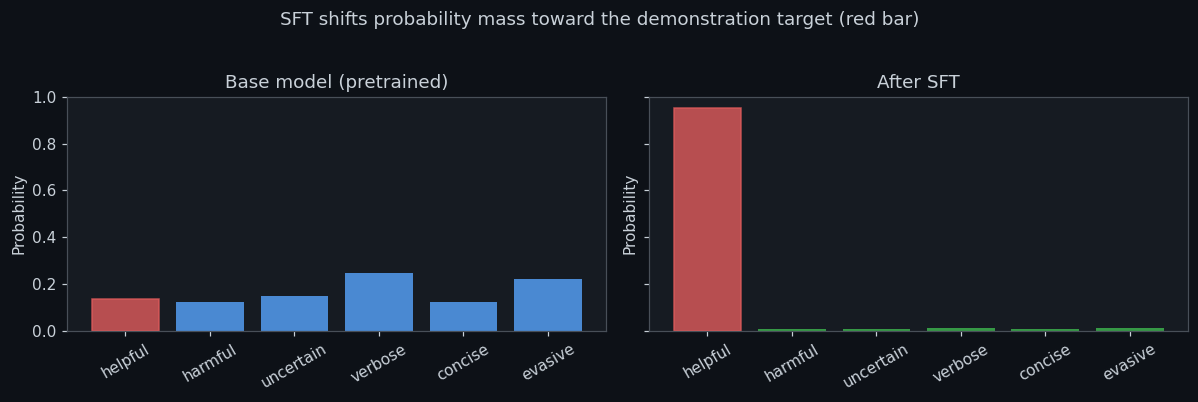

In [4]:
# ── Before / after comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

for ax, probs, title, color in zip(
    axes,
    [base_probs, sft_probs],
    ['Base model (pretrained)', 'After SFT'],
    [BLUE, GREEN]
):
    bars = ax.bar(VOCAB, probs, color=color, alpha=0.8)
    bars[target_idx].set_color(ACCENT)
    ax.set_title(title, color=TEXT)
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('SFT shifts probability mass toward the demonstration target (red bar)', color=TEXT, y=1.03)
plt.tight_layout()
plt.show()

## Part 3 — Stage 2: The Reward Model

### The core idea

Instead of writing a scoring function by hand, we *learn* one from human comparisons.

The setup: a human is shown a prompt and two responses (A and B) generated by the SFT model. They pick which they prefer. This generates a dataset of pairs:

$$\mathcal{D} = \{(x^{(i)}, y_w^{(i)}, y_l^{(i)})\}$$

Where $x$ is the prompt, $y_w$ is the **w**inning (preferred) response, $y_l$ is the **l**osing response.

### The reward model architecture

Take the SFT model. Replace the final token-prediction head with a scalar output head. This network $r_\phi$ maps (prompt, response) → a single real number representing quality.

### The loss function

We want $r_\phi(x, y_w) > r_\phi(x, y_l)$ for every preference pair. The standard approach is to model this as a **Bradley-Terry preference model**:

$$P(y_w \succ y_l) = \sigma(r_\phi(x, y_w) - r_\phi(x, y_l))$$

The probability that $y_w$ is preferred over $y_l$ is the sigmoid of their reward difference. This makes intuitive sense: a large positive difference → high confidence that $y_w$ is better; difference near zero → the model is uncertain.

Maximise the log-likelihood of the observed preferences:

$$\mathcal{L}_{RM} = -\mathbb{E}_{(x, y_w, y_l) \sim \mathcal{D}} \left[ \log \sigma(r_\phi(x, y_w) - r_\phi(x, y_l)) \right]$$

This is just binary cross-entropy where the "logit" is the reward gap.

In [5]:
# ── Reward model from scratch ──────────────────────────────────────────────────
# I'll represent responses as fixed feature vectors.
# In practice these are embeddings from the SFT model's last hidden layer.
# Features: [helpfulness, factual_accuracy, conciseness, politeness, safety]

N_FEATURES = 5
FEATURE_NAMES = ['helpfulness', 'accuracy', 'conciseness', 'politeness', 'safety']

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

class RewardModel:
    """Linear reward model: r(x) = w · x + b."""
    def __init__(self, n_features):
        self.w = np.random.randn(n_features) * 0.1
        self.b = 0.0

    def score(self, features):
        """Scalar reward for a response feature vector."""
        return float(self.w @ features + self.b)

    def loss(self, features_w, features_l):
        """
        Bradley-Terry loss for one preference pair.
        features_w: winner features, features_l: loser features.
        """
        r_w = self.score(features_w)
        r_l = self.score(features_l)
        # -log σ(r_w - r_l)
        return -np.log(sigmoid(r_w - r_l) + 1e-10)

    def update(self, features_w, features_l, lr=0.05):
        """
        Gradient step on the Bradley-Terry loss.
        
        dL/d(r_w) = -(1 - σ(r_w - r_l))  ← want r_w higher
        dL/d(r_l) =  (1 - σ(r_w - r_l))  ← want r_l lower
        
        Since r = w·x + b:
        dL/dw = dL/dr · x
        """
        r_w   = self.score(features_w)
        r_l   = self.score(features_l)
        gap   = sigmoid(r_w - r_l)         # current P(w preferred)
        alpha = 1 - gap                     # how wrong we are

        # Gradients: push r_w up, r_l down
        grad_w = -alpha * features_w
        grad_l =  alpha * features_l

        self.w -= lr * (grad_w + grad_l)
        self.b -= lr * (-alpha + alpha)     # bias gradient cancels here
        return self.loss(features_w, features_l)

print("Reward model defined.")
print(f"Features: {FEATURE_NAMES}")

Reward model defined.
Features: ['helpfulness', 'accuracy', 'conciseness', 'politeness', 'safety']


In [7]:
# ── Generate synthetic preference dataset ─────────────────────────────────────
# Each response is a feature vector in [0,1]^5.
# "Ground truth" quality: a weighted combination we don't tell the model.
# Human labellers see pairs and pick the higher-quality one (with some noise).

TRUE_WEIGHTS = np.array([0.40, 0.30, 0.10, 0.10, 0.10])  # helpfulness matters most

def true_quality(features):
    return TRUE_WEIGHTS @ features

def human_preference(features_a, features_b, noise=0.1):
    """
    Simulated human labeller: picks the higher-quality response,
    but with some noise (humans aren't perfectly consistent).
    Returns (winner_features, loser_features).
    """
    q_a = true_quality(features_a) + np.random.normal(0, noise)
    q_b = true_quality(features_b) + np.random.normal(0, noise)
    if q_a >= q_b:
        return features_a, features_b
    return features_b, features_a

# Generate 500 preference pairs
N_PAIRS = 500
preferences = []
for _ in range(N_PAIRS):
    fa = np.random.uniform(0, 1, N_FEATURES)
    fb = np.random.uniform(0, 1, N_FEATURES)
    fw, fl = human_preference(fa, fb)
    preferences.append((fw, fl))

print(f"Generated {N_PAIRS} preference pairs.")
print(f"\nExample pair:")
fw, fl = preferences[0]
print(f"  Winner features: {fw.round(3)}  quality={true_quality(fw):.3f}")
print(f"  Loser  features: {fl.round(3)}  quality={true_quality(fl):.3f}")

Generated 500 preference pairs.

Example pair:
  Winner features: [0.367 0.526 0.809 0.362 0.524]  quality=0.474
  Loser  features: [0.485 0.778 0.382 0.443 0.376]  quality=0.548


In [8]:
# ── Train the reward model ────────────────────────────────────────────────────
np.random.seed(7)
rm = RewardModel(N_FEATURES)

n_epochs = 8
all_losses = []

for epoch in range(n_epochs):
    epoch_losses = []
    np.random.shuffle(preferences)
    for fw, fl in preferences:
        loss = rm.update(fw, fl, lr=0.02)
        epoch_losses.append(loss)
    all_losses.extend(epoch_losses)
    print(f"Epoch {epoch+1:2d} | mean loss: {np.mean(epoch_losses):.4f}")

print(f"\nLearned weights: {rm.w.round(4)}")
print(f"True weights:    {TRUE_WEIGHTS}")

Epoch  1 | mean loss: 0.6137
Epoch  2 | mean loss: 0.5342
Epoch  3 | mean loss: 0.4927
Epoch  4 | mean loss: 0.4685
Epoch  5 | mean loss: 0.4531
Epoch  6 | mean loss: 0.4427
Epoch  7 | mean loss: 0.4352
Epoch  8 | mean loss: 0.4298

Learned weights: [3.3322 1.9861 0.4525 0.3689 0.7886]
True weights:    [0.4 0.3 0.1 0.1 0.1]


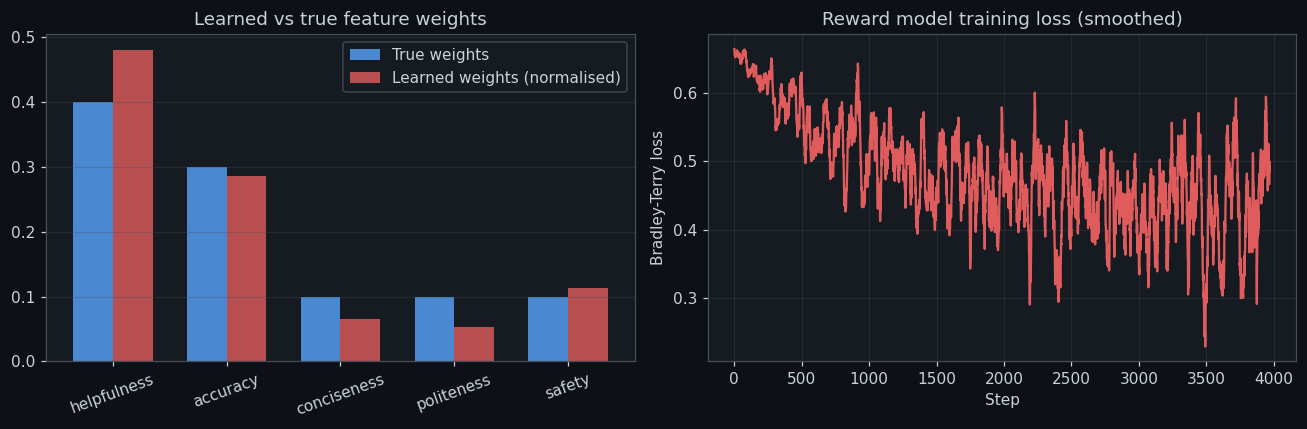

In [9]:
# ── Visualise: did it learn the right weights? ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Weight comparison
ax = axes[0]
x = np.arange(N_FEATURES)
w = 0.35
ax.bar(x - w/2, TRUE_WEIGHTS,  width=w, color=BLUE,   alpha=0.8, label='True weights')
ax.bar(x + w/2, rm.w / rm.w.sum(), width=w, color=ACCENT, alpha=0.8, label='Learned weights (normalised)')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, rotation=20)
ax.set_title('Learned vs true feature weights', color=TEXT)
ax.legend()
ax.grid(True, axis='y')

# Loss curve
ax = axes[1]
window = 30
smooth = np.convolve(all_losses, np.ones(window)/window, mode='valid')
ax.plot(smooth, color=ACCENT, linewidth=1.5)
ax.set_title('Reward model training loss (smoothed)', color=TEXT)
ax.set_xlabel('Step')
ax.set_ylabel('Bradley-Terry loss')
ax.grid(True)

plt.tight_layout()
plt.show()

Preference prediction accuracy: 95.5%
Mean reward gap (winner - loser): 1.3554

A random model would score 50%. Accuracy above 80% is typically
sufficient to provide useful gradients in Stage 3.


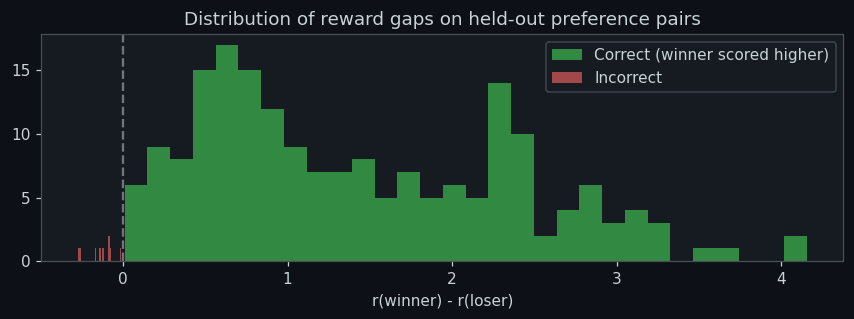

In [10]:
# ── How well does the reward model predict preferences? ───────────────────────
# On held-out pairs: does the reward model rank winner above loser?

n_test = 200
correct = 0
reward_gaps = []

for _ in range(n_test):
    fa = np.random.uniform(0, 1, N_FEATURES)
    fb = np.random.uniform(0, 1, N_FEATURES)
    fw, fl = human_preference(fa, fb, noise=0.0)  # no noise for evaluation

    r_w = rm.score(fw)
    r_l = rm.score(fl)
    reward_gaps.append(r_w - r_l)
    if r_w > r_l:
        correct += 1

accuracy = correct / n_test
print(f"Preference prediction accuracy: {accuracy:.1%}")
print(f"Mean reward gap (winner - loser): {np.mean(reward_gaps):.4f}")
print(f"\nA random model would score 50%. Accuracy above 80% is typically")
print(f"sufficient to provide useful gradients in Stage 3.")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist([g for g in reward_gaps if g > 0], bins=30, color=GREEN,  alpha=0.7, label='Correct (winner scored higher)')
ax.hist([g for g in reward_gaps if g < 0], bins=30, color=ACCENT, alpha=0.7, label='Incorrect')
ax.axvline(0, color=TEXT, linestyle='--', alpha=0.5)
ax.set_title('Distribution of reward gaps on held-out preference pairs', color=TEXT)
ax.set_xlabel('r(winner) - r(loser)')
ax.legend()
plt.tight_layout()
plt.show()

## Part 4 — The Bradley-Terry model: why this loss function?

Worth pausing on why this particular loss is the right choice.

The **Bradley-Terry model** is a classical statistical model for paired comparisons. If items $i$ and $j$ have strengths $\lambda_i$ and $\lambda_j$, the probability that $i$ beats $j$ is:

$$P(i \succ j) = \frac{\lambda_i}{\lambda_i + \lambda_j}$$

If we let $\lambda_i = e^{r_i}$ (so reward is log-strength), this becomes:

$$P(i \succ j) = \frac{e^{r_i}}{e^{r_i} + e^{r_j}} = \sigma(r_i - r_j)$$

Which is exactly the sigmoid of the reward difference — the formula we used.

Three properties that make this a good choice:

1. **Transitivity is built in**: if A usually beats B and B usually beats C, the model implies A usually beats C. Human preferences aren't always transitive, but assuming they roughly are is a reasonable prior.

2. **Only the gap matters**: $\sigma(r_w - r_l)$ depends only on the *difference* in rewards, not their absolute values. This means the reward model is only learning a *ranking*, not an absolute scale. The reward values themselves are meaningless outside the comparisons that trained them.

3. **Noisy labels are handled gracefully**: when humans are uncertain (the quality difference is small), the model appropriately assigns moderate loss even if it gets the ranking right — it's not overconfident on close comparisons.

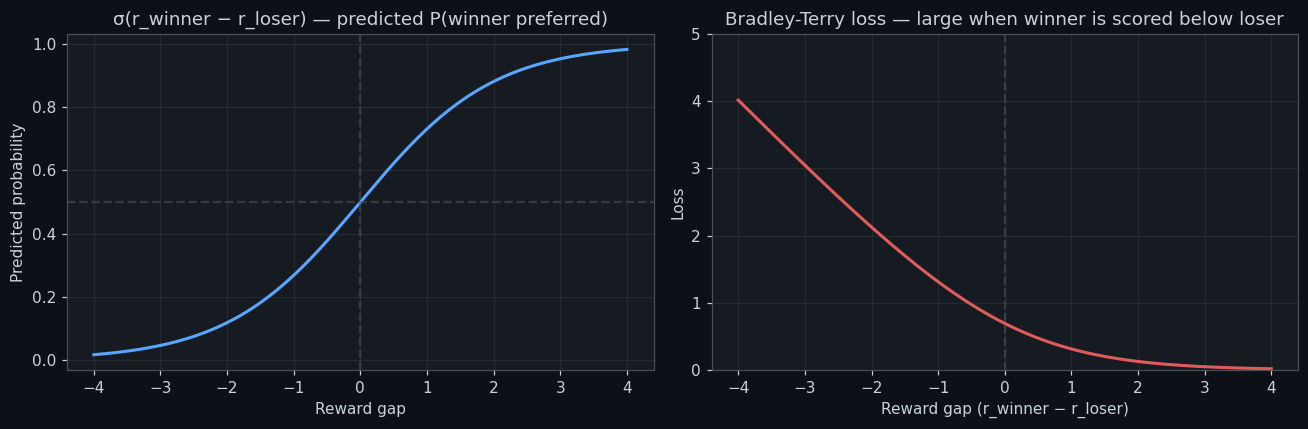

When r_winner >> r_loser: gap is large, loss is near zero — the model is confident and correct.
When r_winner << r_loser: gap is negative, loss is large — strong gradient signal to correct this.
When gap ≈ 0: moderate loss even if technically correct — appropriate uncertainty on close calls.


In [11]:
# ── Visualise: how the loss behaves as a function of reward gap ───────────────
gaps = np.linspace(-4, 4, 300)
prob_correct = sigmoid(gaps)
loss_vals    = -np.log(sigmoid(gaps) + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(gaps, prob_correct, color=BLUE, linewidth=2)
ax.axhline(0.5, color=MUTED, linestyle='--', alpha=0.6)
ax.axvline(0,   color=MUTED, linestyle='--', alpha=0.6)
ax.set_title('σ(r_winner − r_loser) — predicted P(winner preferred)', color=TEXT)
ax.set_xlabel('Reward gap')
ax.set_ylabel('Predicted probability')
ax.grid(True)

ax = axes[1]
ax.plot(gaps, loss_vals, color=ACCENT, linewidth=2)
ax.axvline(0, color=MUTED, linestyle='--', alpha=0.6)
ax.set_ylim(0, 5)
ax.set_title('Bradley-Terry loss — large when winner is scored below loser', color=TEXT)
ax.set_xlabel('Reward gap (r_winner − r_loser)')
ax.set_ylabel('Loss')
ax.grid(True)

plt.tight_layout()
plt.show()

print("When r_winner >> r_loser: gap is large, loss is near zero — the model is confident and correct.")
print("When r_winner << r_loser: gap is negative, loss is large — strong gradient signal to correct this.")
print("When gap ≈ 0: moderate loss even if technically correct — appropriate uncertainty on close calls.")

## Part 5 — Stage 3: RL Fine-Tuning (structural overview)

This is where the trained reward model becomes the feedback signal for a reinforcement learning loop.

### The setup

- **Policy** $\pi_\theta$: the SFT model, now treated as an RL agent. At each step, it samples a response to a prompt.
- **Reward**: the reward model $r_\phi$ scores the response. This is the signal the policy is optimised against.
- **Objective**: update $\pi_\theta$ to produce responses that score higher under $r_\phi$.

### Why not just do supervised learning on high-reward examples?

You could sample many responses, keep the ones with high reward, and fine-tune on those. This is called **rejection sampling** and is actually used in some pipelines. But it's inefficient — you discard most samples — and it doesn't extrapolate beyond the best examples you happened to generate.

RL allows the policy to *explore* and receive gradient signal from the full distribution of responses, not just the top ones.

### The full objective

$$\max_{\pi_\theta} \; \mathbb{E}_{x \sim \mathcal{D},\; y \sim \pi_\theta(\cdot|x)} \left[ r_\phi(x, y) - \beta \log \frac{\pi_\theta(y|x)}{\pi_{SFT}(y|x)} \right]$$

The second term is critical. Let's decode it:

| Term | What it is |
|------|------------|
| $r_\phi(x, y)$ | Reward model score — maximise this |
| $\log \frac{\pi_\theta(y|x)}{\pi_{SFT}(y|x)}$ | KL divergence from the SFT model — a penalty |
| $\beta$ | Controls how much we penalise drifting from SFT |

### Why the KL penalty?

Without it, the policy would **reward hack**: find responses that score highly under the reward model but don't actually represent good behaviour. The reward model is an imperfect proxy — it was trained on a finite set of human comparisons and will have blind spots.

A policy left unconstrained will find those blind spots and exploit them. It might learn to produce verbose, flattering non-answers that humans rated highly in comparisons but that aren't actually useful. This is Goodhart's Law applied to RL: *when a measure becomes a target, it ceases to be a good measure*.

The KL penalty keeps the policy close to the SFT model, which had sane behaviour to begin with. $\beta$ is a dial between "optimise reward aggressively" and "stay close to SFT".

In [12]:
# ── Demonstrate the KL penalty ────────────────────────────────────────────────
# Show what happens to a policy distribution as we optimise reward with
# and without the KL constraint.

def kl_divergence(p, q):
    """KL(p || q) — how much p diverges from reference q."""
    p = np.clip(p, 1e-10, 1)
    q = np.clip(q, 1e-10, 1)
    return float(np.sum(p * np.log(p / q)))

# SFT policy: our starting point (balanced distribution)
sft_probs_ref = np.array([0.30, 0.05, 0.20, 0.15, 0.20, 0.10])  # [helpful, harmful, uncertain, verbose, concise, evasive]

# Reward model has a blind spot: rates 'verbose' responses very highly
# (perhaps because verbose responses *look* thorough in pairwise comparisons)
reward_scores = np.array([0.8, -2.0, 0.3, 0.9, 0.5, 0.1])  # verbose gets 0.9, harmful penalised

def expected_reward(probs):
    return float(probs @ reward_scores)

def rlhf_objective(probs, beta):
    return expected_reward(probs) - beta * kl_divergence(probs, sft_probs_ref)

# Optimise: push policy toward high reward, with varying KL penalty
betas = [0.0, 0.1, 0.5, 2.0]
optimised_policies = {}

for beta in betas:
    logits = np.log(sft_probs_ref + 1e-10).copy()
    for _ in range(300):
        probs = softmax(logits)
        # Gradient of objective w.r.t. logits
        # d(E[r])/dlogits ≈ r - E[r] (policy gradient)
        # d(KL)/dlogits ≈ log(p/q) + 1 - sum(p*(log(p/q)+1))
        r_grad   = reward_scores - expected_reward(probs)
        kl_grad  = np.log(probs / sft_probs_ref) + 1 - kl_divergence(probs, sft_probs_ref)
        grad     = r_grad - beta * kl_grad
        logits  += 0.01 * grad
    optimised_policies[beta] = softmax(logits)

print("Optimised policies at different β values:")
print(f"{'Token':12s}", end='')
for beta in betas:
    print(f"  β={beta:3.1f}", end='')
print()
for i, token in enumerate(VOCAB):
    print(f"{token:12s}", end='')
    for beta in betas:
        print(f"  {optimised_policies[beta][i]:.3f}", end='')
    print()

Optimised policies at different β values:
Token         β=0.0  β=0.1  β=0.5  β=2.0
helpful       0.468  0.456  0.413  0.345
harmful       0.000  0.000  0.001  0.014
uncertain     0.070  0.083  0.126  0.179
verbose       0.316  0.296  0.241  0.182
concise       0.127  0.140  0.173  0.198
evasive       0.019  0.025  0.046  0.081


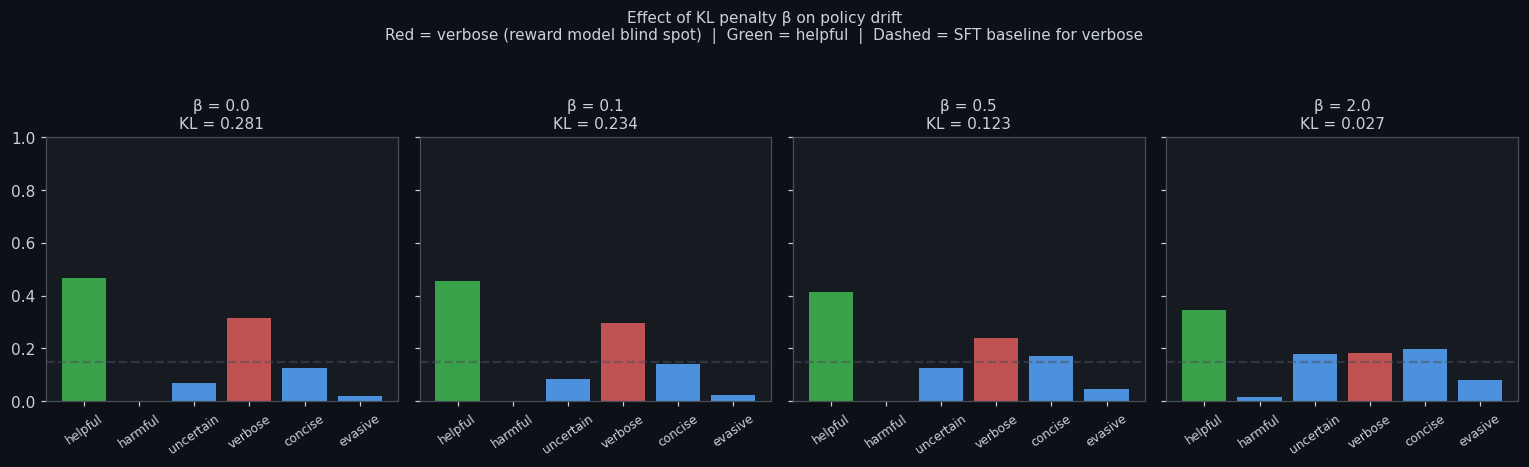

β=0: no constraint — policy collapses onto 'verbose' (reward hacking)
β=2: strong constraint — policy stays close to SFT, modest reward improvement
β≈0.5: typical practical range — reward improves without catastrophic drift


In [13]:
fig, axes = plt.subplots(1, len(betas), figsize=(14, 4), sharey=True)

verbose_idx = VOCAB.index('verbose')
helpful_idx = VOCAB.index('helpful')

for ax, beta in zip(axes, betas):
    probs = optimised_policies[beta]
    colors = [ACCENT if i == verbose_idx else
              GREEN  if i == helpful_idx else
              BLUE
              for i in range(len(VOCAB))]
    ax.bar(VOCAB, probs, color=colors, alpha=0.85)
    ax.set_title(f'β = {beta}\nKL = {kl_divergence(probs, sft_probs_ref):.3f}', color=TEXT, fontsize=10)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.axhline(sft_probs_ref[verbose_idx], color=MUTED, linestyle='--', alpha=0.5)

fig.suptitle(
    'Effect of KL penalty β on policy drift\n'
    'Red = verbose (reward model blind spot)  |  Green = helpful  |  Dashed = SFT baseline for verbose',
    color=TEXT, y=1.05, fontsize=10
)
plt.tight_layout()
plt.show()

print("β=0: no constraint — policy collapses onto 'verbose' (reward hacking)")
print("β=2: strong constraint — policy stays close to SFT, modest reward improvement")
print("β≈0.5: typical practical range — reward improves without catastrophic drift")

## Part 6 — Why PPO? Why not simpler RL?

The objective above needs an RL algorithm to optimise it. The naive approach — REINFORCE (vanilla policy gradients) — works in principle but has two problems in this setting:

1. **High variance**: the gradient estimate from a single trajectory is noisy. You need many samples to get a stable signal, which means many expensive forward passes through the LM.

2. **Large update problem**: policy gradient methods have no constraint on how much the policy changes in a single update. A bad update can destroy the policy, and unlike supervised learning, you can't just "go back" — the new policy generates different data, which changes the loss landscape.

**PPO (Proximal Policy Optimisation, Schulman et al. 2017)** addresses both:

- Uses a **clipped surrogate objective** that constrains how much the policy is allowed to change per update
- Uses a **value function** (the "critic") to reduce variance in the gradient estimate

The clipped objective:

$$\mathcal{L}^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\left( \rho_t(\theta) \hat{A}_t, \; \text{clip}(\rho_t(\theta), 1-\epsilon, 1+\epsilon) \hat{A}_t \right) \right]$$

Where:
- $\rho_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{old}(a_t|s_t)}$ is the **probability ratio** — how much more/less likely this action is under the new policy vs old
- $\hat{A}_t$ is the **advantage estimate** — was this action better or worse than expected?
- $\epsilon$ (typically 0.1–0.2) **clips** the ratio, preventing updates that move too far from the old policy

The full mechanics — value functions, advantage estimation, the actor-critic architecture — are in the companion Actor-Critic notebook. Here, the key insight is: **PPO is the algorithm that makes Stage 3 stable enough to work at scale**.

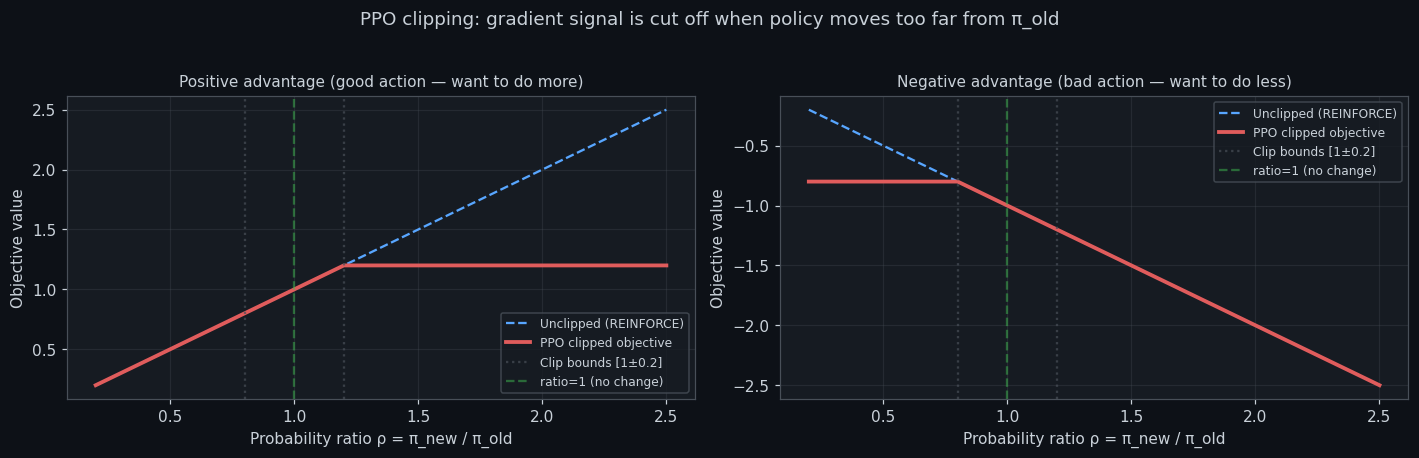

Left: positive advantage (this action was good — increase its probability)
  Unclipped: incentive keeps growing as ratio increases → can over-update
  PPO: incentive is flat once ratio > 1+ε → no reward for going further

Right: negative advantage (bad action — decrease its probability)
  Unclipped: keeps pushing ratio down with increasing force
  PPO: stops penalising once ratio < 1-ε → stable floor


In [14]:
# ── Visualise the PPO clipping mechanism ──────────────────────────────────────
# Show how clipping prevents large policy updates

ratios    = np.linspace(0.2, 2.5, 300)
epsilon   = 0.2
A_pos     = 1.0   # positive advantage: this action was better than expected
A_neg     = -1.0  # negative advantage: this action was worse than expected

def ppo_objective(ratio, advantage, eps):
    unclipped = ratio * advantage
    clipped   = np.clip(ratio, 1 - eps, 1 + eps) * advantage
    return np.minimum(unclipped, clipped)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, A, title in zip(axes, [A_pos, A_neg],
                         ['Positive advantage (good action — want to do more)',
                          'Negative advantage (bad action — want to do less)']):
    unclipped = ratios * A
    clipped   = np.clip(ratios, 1-epsilon, 1+epsilon) * A
    objective = np.minimum(unclipped, clipped)

    ax.plot(ratios, unclipped,  color=BLUE,   linewidth=1.5, linestyle='--', label='Unclipped (REINFORCE)')
    ax.plot(ratios, objective,  color=ACCENT,  linewidth=2.5, label='PPO clipped objective')
    ax.axvline(1 - epsilon, color=MUTED, linestyle=':', alpha=0.7)
    ax.axvline(1 + epsilon, color=MUTED, linestyle=':', alpha=0.7, label=f'Clip bounds [1±{epsilon}]')
    ax.axvline(1.0, color=GREEN, linestyle='--', alpha=0.5, label='ratio=1 (no change)')
    ax.set_xlabel('Probability ratio ρ = π_new / π_old')
    ax.set_ylabel('Objective value')
    ax.set_title(title, color=TEXT, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle('PPO clipping: gradient signal is cut off when policy moves too far from π_old', color=TEXT, y=1.03)
plt.tight_layout()
plt.show()

print("Left: positive advantage (this action was good — increase its probability)")
print("  Unclipped: incentive keeps growing as ratio increases → can over-update")
print("  PPO: incentive is flat once ratio > 1+ε → no reward for going further")
print()
print("Right: negative advantage (bad action — decrease its probability)")
print("  Unclipped: keeps pushing ratio down with increasing force")
print("  PPO: stops penalising once ratio < 1-ε → stable floor")

## Part 7 — The complete picture

```
┌─────────────────────────────────────────────────────────────────────────┐
│  STAGE 1: Supervised Fine-Tuning                                        │
│                                                                         │
│  Data:    (prompt, ideal response) pairs — human written                │
│  Loss:    cross-entropy on next token prediction                        │
│  Output:  SFT model π_SFT — knows how to follow instructions           │
└────────────────────────────┬────────────────────────────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────────────┐
│  STAGE 2: Reward Model Training                                         │
│                                                                         │
│  Data:    (prompt, response_A, response_B, human_preference) tuples     │
│  Loss:    Bradley-Terry: -log σ(r_winner - r_loser)                    │
│  Output:  Reward model r_φ — scalar quality score for any response     │
└────────────────────────────┬────────────────────────────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────────────┐
│  STAGE 3: RL Fine-Tuning with PPO                ← Actor-Critic notebook│
│                                                                         │
│  Policy:  π_θ initialised from π_SFT                                   │
│  Reward:  r_φ(x, y) − β·KL(π_θ ‖ π_SFT)                              │
│  Method:  PPO — clipped surrogate + value function for variance         │
│  Output:  Final aligned model                                           │
└─────────────────────────────────────────────────────────────────────────┘
```

### What I find interesting about this pipeline

The reward model is doing something subtle: it's learning a *proxy* for human values from noisy, inconsistent, context-free pairwise comparisons. The humans providing preferences don't agree with each other, can't articulate why they prefer one response over another, and are working without full context about how the model will use the signal. Yet the pipeline works well enough to produce a useful alignment signal.

The KL penalty is an acknowledgement that this proxy is imperfect. It's a built-in scepticism about the reward model — don't optimise it too hard, because the model you end up with will be optimised against the *proxy*, not the underlying thing the proxy was trying to measure.

This tension — between optimising the measurable proxy and preserving the unmeasurable original objective — is the central unsolved problem in AI alignment. RLHF manages it with a regularisation term. It works well enough in practice. Whether it scales as models get more capable is an open question.

## Summary

| Stage | Data | Loss | Output |
|-------|------|------|--------|
| **SFT** | (prompt, ideal response) | Cross-entropy on tokens | Model that follows instructions |
| **Reward Model** | (prompt, winner, loser) | Bradley-Terry: $-\log \sigma(r_w - r_l)$ | Scalar quality scorer |
| **PPO** | Sampled responses | Clipped surrogate − β·KL | Aligned policy |

---

### The key equations

**Reward model loss:**
$$\boxed{\mathcal{L}_{RM} = -\mathbb{E}\left[\log \sigma(r_\phi(x, y_w) - r_\phi(x, y_l))\right]}$$

**RLHF objective:**
$$\boxed{\max_{\pi_\theta} \; \mathbb{E}\left[r_\phi(x, y) - \beta \log \frac{\pi_\theta(y|x)}{\pi_{SFT}(y|x)}\right]}$$

---

## Things to try

- Change `TRUE_WEIGHTS` so that `safety` matters most — does the reward model still learn the right ranking?
- Increase the `noise` parameter in `human_preference` — at what noise level does the reward model stop being useful?
- Try `beta=0` and `beta=10` in the KL penalty section — characterise the tradeoff precisely
- What happens to the PPO clipping plot if you change `epsilon` to 0.5? To 0.01?